# Phát Hiện Bất Thường Theo Luật Nghiệp Vụ dựa trên Session người dùng trong web thương mại điện tử

## RetailRocket E-Commerce Dataset

Notebook này là bản đồ án nhóm 5 người. Mục tiêu là phát hiện session có hành vi đáng nghi trong web thương mại điện tử dựa trên dữ liệu sự kiện RetailRocket.

Dataset: https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset

Đơn vị phân tích chính là `session_id`, được tạo từ `visitorid` và khoảng nghỉ 30 phút giữa hai sự kiện liên tiếp. Dataset không có nhãn bất thường thật, vì vậy nhãn `is_anomaly_rule` và `anomaly_types` là pseudo-label do nhóm thiết kế bằng luật nghiệp vụ.

## Hệ thống business rules và anomaly types

| Mã | Anomaly type | Mô tả nghiệp vụ | Dấu hiệu chính trong notebook |
| --- | --- | --- | --- |
| BR01 | Bot scraper | Session có hành vi duyệt tự động hoặc quét dữ liệu nhanh. | Nhiều event trong session hoặc tốc độ event/phút cao. |
| BR02 | Ghost buyer | Có giao dịch nhưng không có bước thêm giỏ trong cùng session. | `transaction > 0` và `addtocart = 0`. |
| BR03 | Click fraud | Xem nhiều sản phẩm nhưng không có ý định mua hoặc thêm giỏ. | Nhiều `view`, không có `addtocart`, không có `transaction`. |
| BR04 | Rapid-fire | Các thao tác diễn ra quá sát nhau, giống bot/script. | Có event liên tiếp dưới 1 giây hoặc tỉ lệ rapid-fire cao. |
| BR05 | Night crawler | Session hoạt động chủ yếu vào khung giờ đêm. | Tỉ lệ event 0h-5h cao và session đủ số event tối thiểu. |
| BR06 | Item hoarding | Thêm cùng một sản phẩm vào giỏ nhiều lần trong một session. | `max_same_item_atc` vượt ngưỡng. |
| BR07 | Session bomb | Session xem/quét quá nhiều item khác nhau. | `unique_items` cao. |
| BR08 | Sequence violation | Thứ tự hành vi bất thường: mua trước khi xem/thêm giỏ cùng item. | `transaction` xuất hiện trước `view/addtocart` của cùng item trong session. |
| BR09 | Transaction burst | Session có số lượng giao dịch cao bất thường. | `n_transaction` vượt ngưỡng. |
| BR10 | Cart abandonment | Thêm nhiều sản phẩm vào giỏ nhưng không giao dịch. | `n_addtocart` cao và `n_transaction = 0`. |
| BR11 | Repeated view spam | Xem lặp lại cùng một item quá nhiều lần. | `max_same_item_view` vượt ngưỡng. |
| BR12 | Category scanning | Quét nhiều nhóm danh mục sản phẩm trong một session. | `unique_categories` cao nếu dữ liệu category khả dụng. |

Các rule này dùng để gắn nhãn multi-label cho session. Một session có thể vừa là `Bot scraper`, vừa là `Rapid-fire`, vừa là `Session bomb`. Các thuật toán ML dùng pseudo-label này để so sánh/mô phỏng, không được diễn giải như nhãn gian lận thật.

## Phân công thuật toán

| Người | Thuật toán | Loại | Vai trò trong đồ án |
| --- | --- | --- | --- |
| 1 | XGBoost | Phân loại có giám sát | Mô hình boosting mạnh, xử lý dữ liệu phi tuyến và mất cân bằng lớp |
| 2 | Decision Tree | Phân loại có giám sát | Mô hình dễ giải thích, minh họa được luật quyết định |
| 3 | Random Forest | Phân loại có giám sát | Ensemble nhiều cây, ổn định hơn cây đơn và có feature importance |
| 4 | K-Means | Phân cụm không giám sát | Khám phá nhóm session có hành vi khác biệt |
| 5 | Isolation Forest | Phát hiện bất thường không giám sát | Thuật toán chuyên biệt cho anomaly detection |

## 1. Import và cấu hình

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise ImportError(
        "Chua load duoc XGBoost. Cai Python package bang `.venv/bin/python -m pip install xgboost`; "
        "tren macOS can them OpenMP runtime bang `brew install libomp`."
    ) from exc

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
OUTPUT_DIR = Path('.')
DATA_PATH = Path('./data/events.csv')
SESSION_GAP_SEC = 30 * 60

MAX_SUPERVISED_ROWS = 300_000
KMEANS_TRAIN_ROWS = 250_000
IFOREST_TRAIN_ROWS = 250_000
PLOT_SAMPLE_ROWS = 30_000

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
COLORS = {
    'normal': '#2E7D32',
    'anomaly': '#C62828',
    'warning': '#EF6C00',
    'primary': '#1565C0',
    'secondary': '#6A1B9A',
    'dark': '#263238',
    'muted': '#607D8B',
}

print('Thu vien va cau hinh da san sang')

Thu vien va cau hinh da san sang


## 2. Tải dữ liệu, tiền xử lý và tạo session

Session được định nghĩa bằng khoảng nghỉ 30 phút giữa hai event liên tiếp của cùng `visitorid`.

In [2]:
print('Dang tai du lieu events.csv...')
events = pd.read_csv(DATA_PATH)

required_cols = {'timestamp', 'visitorid', 'event', 'itemid', 'transactionid'}
missing_cols = required_cols.difference(events.columns)
if missing_cols:
    raise ValueError(f'Thieu cot bat buoc: {sorted(missing_cols)}')

before_dedup = len(events)
events = events.drop_duplicates().reset_index(drop=True)
duplicate_count = before_dedup - len(events)

events = events[events['event'].isin(['view', 'addtocart', 'transaction'])].copy()

events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['date'] = events['datetime'].dt.date
events['hour'] = events['datetime'].dt.hour
events['dayofweek'] = events['datetime'].dt.dayofweek

events = events.sort_values(['visitorid', 'timestamp', 'event', 'itemid']).reset_index(drop=True)
events['prev_timestamp'] = events.groupby('visitorid')['timestamp'].shift(1)
events['time_diff_sec'] = (events['timestamp'] - events['prev_timestamp']) / 1000

new_session = events['time_diff_sec'].isna() | (events['time_diff_sec'] > SESSION_GAP_SEC)
events['session_number'] = new_session.groupby(events['visitorid']).cumsum().astype('int32')
events['session_id'] = events['visitorid'].astype(str) + '_S' + events['session_number'].astype(str)

events['prev_session_timestamp'] = events.groupby('session_id')['timestamp'].shift(1)
events['time_diff_session_sec'] = (events['timestamp'] - events['prev_session_timestamp']) / 1000

session_count = events['session_id'].nunique()
print(f'So dong duplicate da xoa: {duplicate_count:,}')
print(f'Tong so su kien sau tien xu ly: {len(events):,}')
print(f'So visitor duy nhat: {events["visitorid"].nunique():,}')
print(f'So session tao ra: {session_count:,}')
print(f'Trung binh event/session: {len(events) / session_count:.2f}')
print(f'Thoi gian: {events["datetime"].min()} -> {events["datetime"].max()}')
print('\nPhan phoi event:')
display(events['event'].value_counts().rename_axis('event').reset_index(name='count'))

Dang tai du lieu events.csv...


So dong duplicate da xoa: 460
Tong so su kien sau tien xu ly: 2,755,641
So visitor duy nhat: 1,407,580
So session tao ra: 1,761,675
Trung binh event/session: 1.56
Thoi gian: 2015-05-03 03:00:04.384000 -> 2015-09-18 02:59:47.788000

Phan phoi event:


,event,count
0,view,2664218
1,addtocart,68966
2,transaction,22457


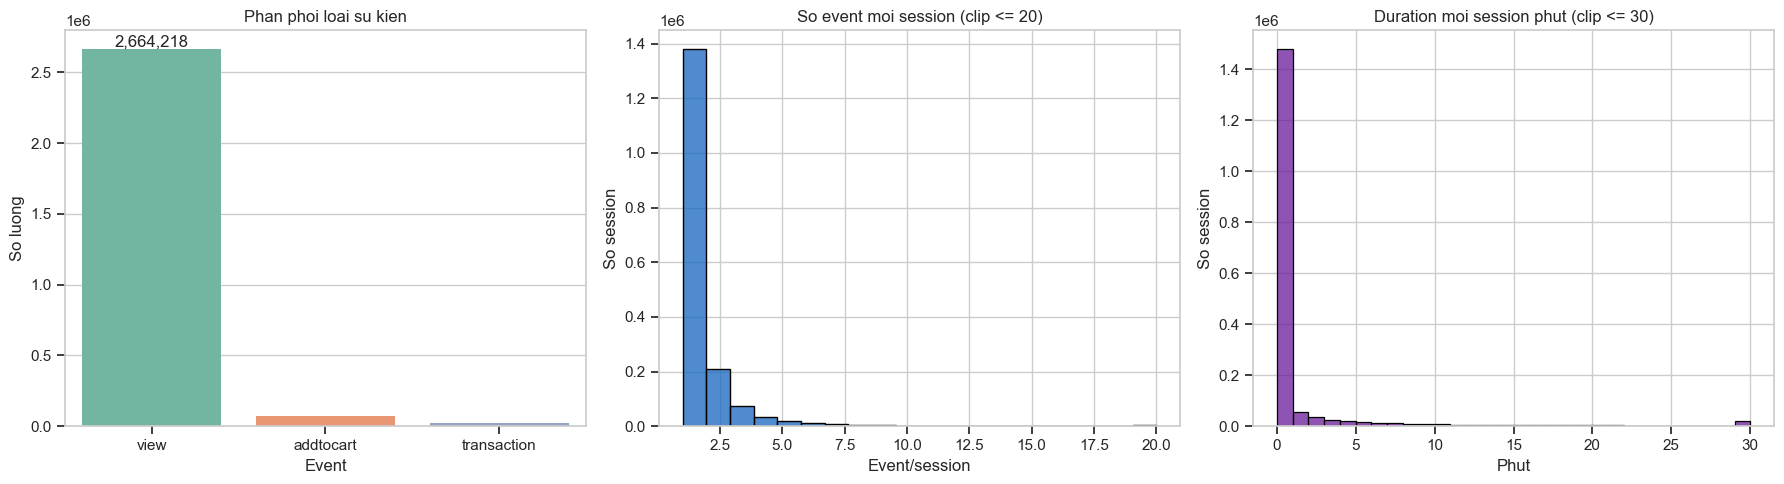

In [3]:
session_sizes = events.groupby('session_id').size()
session_duration = (events.groupby('session_id')['timestamp'].max() - events.groupby('session_id')['timestamp'].min()) / 1000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order = events['event'].value_counts().index
sns.countplot(data=events, x='event', order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Phan phoi loai su kien')
axes[0].set_xlabel('Event')
axes[0].set_ylabel('So luong')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}')

sns.histplot(session_sizes.clip(upper=20), bins=20, color=COLORS['primary'], ax=axes[1])
axes[1].set_title('So event moi session (clip <= 20)')
axes[1].set_xlabel('Event/session')
axes[1].set_ylabel('So session')

sns.histplot((session_duration / 60).clip(upper=30), bins=30, color=COLORS['secondary'], ax=axes[2])
axes[2].set_title('Duration moi session phut (clip <= 30)')
axes[2].set_xlabel('Phut')
axes[2].set_ylabel('So session')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_session_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Xây dựng session behavior profile

Mỗi dòng của bảng profile tương ứng với một `session_id`. `visitorid` chỉ còn là metadata để truy vết người dùng.

In [4]:
print('Dang xay dung session behavior profile...')
df = events.copy()
g = df.groupby('session_id', sort=False)

profile = pd.DataFrame(index=g.size().index)
profile.index.name = 'session_id'
profile['visitorid'] = g['visitorid'].first().astype('int64')
profile['session_number'] = g['session_number'].first().astype('int32')
profile['session_start'] = g['datetime'].min()
profile['session_end'] = g['datetime'].max()
profile['session_start_hour'] = profile['session_start'].dt.hour
profile['session_dayofweek'] = profile['session_start'].dt.dayofweek
profile['total_events'] = g.size().astype('int32')
profile['unique_items'] = g['itemid'].nunique().astype('int32')
profile['active_hours'] = g['hour'].nunique().astype('int16')
profile['session_duration_sec'] = ((g['timestamp'].max() - g['timestamp'].min()) / 1000).astype('float32')

event_counts = df.groupby(['session_id', 'event']).size().unstack(fill_value=0)
event_counts.columns = [f'n_{col}' for col in event_counts.columns]
for col in ['n_view', 'n_addtocart', 'n_transaction']:
    if col not in event_counts.columns:
        event_counts[col] = 0
profile = profile.join(event_counts[['n_view', 'n_addtocart', 'n_transaction']].astype('int32'))
profile['unique_event_types'] = (profile[['n_view', 'n_addtocart', 'n_transaction']] > 0).sum(axis=1).astype('int8')

event_probs = event_counts[['n_view', 'n_addtocart', 'n_transaction']].div(profile['total_events'].clip(lower=1), axis=0)
profile['event_type_entropy'] = (-(event_probs.replace(0, np.nan) * np.log2(event_probs.replace(0, np.nan))).sum(axis=1)).fillna(0).astype('float32')

hour_counts = df.groupby(['session_id', 'hour']).size().unstack(fill_value=0)
hour_probs = hour_counts.div(hour_counts.sum(axis=1).clip(lower=1), axis=0)
profile['hour_entropy'] = (-(hour_probs.replace(0, np.nan) * np.log2(hour_probs.replace(0, np.nan))).sum(axis=1)).fillna(0).astype('float32')

time_diffs = df.dropna(subset=['time_diff_session_sec'])
speed_stats = time_diffs.groupby('session_id')['time_diff_session_sec'].agg(
    min_interval_sec='min',
    mean_interval_sec='mean',
    median_interval_sec='median',
    std_interval_sec='std',
    max_interval_sec='max',
)
profile = profile.join(speed_stats).fillna({
    'min_interval_sec': 0,
    'mean_interval_sec': 0,
    'median_interval_sec': 0,
    'std_interval_sec': 0,
    'max_interval_sec': 0,
})
interval_cols = ['min_interval_sec', 'mean_interval_sec', 'median_interval_sec', 'std_interval_sec', 'max_interval_sec']
profile[interval_cols] = profile[interval_cols].astype('float32')

profile['rapid_fire_count'] = time_diffs[time_diffs['time_diff_session_sec'] < 1].groupby('session_id').size().reindex(profile.index, fill_value=0).astype('int16')
profile['night_events'] = df[df['hour'].between(0, 5)].groupby('session_id').size().reindex(profile.index, fill_value=0).astype('int16')
profile['peak_events'] = df[df['hour'].between(9, 21)].groupby('session_id').size().reindex(profile.index, fill_value=0).astype('int16')
profile['weekend_events'] = df[df['dayofweek'].isin([5, 6])].groupby('session_id').size().reindex(profile.index, fill_value=0).astype('int16')

view_events = df[df['event'] == 'view']
if len(view_events) > 0:
    max_same_item_view = view_events.groupby(['session_id', 'itemid']).size().groupby('session_id').max()
    profile['max_same_item_view'] = max_same_item_view.reindex(profile.index, fill_value=0).astype('int16')
else:
    profile['max_same_item_view'] = 0

atc_events = df[df['event'] == 'addtocart']
if len(atc_events) > 0:
    max_same_item_atc = atc_events.groupby(['session_id', 'itemid']).size().groupby('session_id').max()
    profile['max_same_item_atc'] = max_same_item_atc.reindex(profile.index, fill_value=0).astype('int16')
else:
    profile['max_same_item_atc'] = 0

profile['duration_min'] = (profile['session_duration_sec'] / 60).clip(lower=1).astype('float32')
profile['events_per_minute'] = (profile['total_events'] / profile['duration_min']).astype('float32')
profile['view_rate'] = (profile['n_view'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['atc_rate'] = (profile['n_addtocart'] / profile['n_view'].clip(lower=1)).astype('float32')
profile['buy_rate'] = (profile['n_transaction'] / profile['n_view'].clip(lower=1)).astype('float32')
profile['night_ratio'] = (profile['night_events'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['peak_ratio'] = (profile['peak_events'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['weekend_ratio'] = (profile['weekend_events'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['rapid_ratio'] = (profile['rapid_fire_count'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['items_per_event'] = (profile['unique_items'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['view_to_cart_ratio'] = (profile['n_view'] / profile['n_addtocart'].clip(lower=1)).astype('float32')
profile['cart_to_transaction_ratio'] = (profile['n_addtocart'] / profile['n_transaction'].clip(lower=1)).astype('float32')

# Optional category features from RetailRocket item properties.
profile['unique_categories'] = 0
profile['unique_parent_categories'] = 0
try:
    item_props_1 = pd.read_csv('./data/item_properties_part1.csv', usecols=['itemid', 'property', 'value'])
    item_props_2 = pd.read_csv('./data/item_properties_part2.csv', usecols=['itemid', 'property', 'value'])
    item_categories = pd.concat([item_props_1, item_props_2], ignore_index=True)
    item_categories = item_categories[item_categories['property'].astype(str) == 'categoryid'][['itemid', 'value']]
    item_categories['categoryid'] = pd.to_numeric(item_categories['value'], errors='coerce')
    item_categories = item_categories.dropna(subset=['categoryid']).drop_duplicates('itemid')
    item_categories['categoryid'] = item_categories['categoryid'].astype('int64')

    category_tree = pd.read_csv('./data/category_tree.csv')
    category_parent = category_tree[['categoryid', 'parentid']].drop_duplicates('categoryid')
    item_categories = item_categories.merge(category_parent, on='categoryid', how='left')

    session_items = df[['session_id', 'itemid']].drop_duplicates()
    session_items = session_items.merge(item_categories[['itemid', 'categoryid', 'parentid']], on='itemid', how='left')
    profile['unique_categories'] = session_items.groupby('session_id')['categoryid'].nunique().reindex(profile.index, fill_value=0).astype('int16')
    profile['unique_parent_categories'] = session_items.groupby('session_id')['parentid'].nunique().reindex(profile.index, fill_value=0).astype('int16')
    print('Da bo sung category features tu item_properties va category_tree')
except Exception as exc:
    print(f'Bo qua category features vi khong load duoc item properties: {exc}')

print(f'Session profile shape: {profile.shape}')
print(f'Session_id unique: {profile.index.is_unique}')
display(profile.head())

Dang xay dung session behavior profile...


Da bo sung category features tu item_properties va category_tree
Session profile shape: (1761675, 41)
Session_id unique: True


,visitorid,session_number,session_start,session_end,session_start_hour,session_dayofweek,total_events,unique_items,active_hours,session_duration_sec,...,buy_rate,night_ratio,peak_ratio,weekend_ratio,rapid_ratio,items_per_event,view_to_cart_ratio,cart_to_transaction_ratio,unique_categories,unique_parent_categories
session_id,,,,,,,,,,,,,,,,,,,,,
0_S1,0,1,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,20,4,3,3,1,327.735992,...,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0.0,3,2
1_S1,1,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,17,3,1,1,1,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1,1
2_S1,2,1,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,17,4,8,4,2,1753.277954,...,0.0,0.0,1.0,0.0,0.0,0.5,8.0,0.0,2,1
3_S1,3,1,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,7,5,1,1,1,0.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1,1
4_S1,4,1,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,21,1,1,1,1,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0,0


In [5]:
summary_cols = [
    'total_events', 'unique_items', 'unique_categories', 'unique_parent_categories',
    'session_duration_sec', 'events_per_minute', 'n_view', 'n_addtocart', 'n_transaction',
    'rapid_fire_count', 'rapid_ratio', 'night_ratio', 'max_same_item_view', 'max_same_item_atc',
    'event_type_entropy', 'hour_entropy',
]
profile_summary = profile[summary_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
print('Thong ke cac dac trung session chinh:')
display(profile_summary)

Thong ke cac dac trung session chinh:


,count,mean,std,min,50%,75%,90%,95%,99%,max
total_events,1761675.0,1.564216,2.599172,1.000000,1.0,1.0,2.000000,4.00000,9.000000,417.000000
unique_items,1761675.0,1.332739,1.784379,1.000000,1.0,1.0,2.000000,3.00000,6.000000,389.000000
unique_categories,1761675.0,0.964344,0.892530,0.000000,1.0,1.0,1.000000,1.00000,3.000000,114.000000
unique_parent_categories,1761675.0,0.942344,0.755826,0.000000,1.0,1.0,1.000000,1.00000,2.000000,79.000000
session_duration_sec,1761675.0,105.243446,499.529755,0.000000,0.0,0.0,213.162402,624.14751,1792.538149,43704.246094
events_per_minute,1761675.0,1.039757,0.440438,0.048184,1.0,1.0,1.116754,2.00000,3.000000,29.099926
n_view,1761675.0,1.512321,2.352375,0.000000,1.0,1.0,2.000000,4.00000,8.000000,417.000000
n_addtocart,1761675.0,0.039148,0.397012,0.000000,0.0,0.0,0.000000,0.00000,1.000000,114.000000
n_transaction,1761675.0,0.012748,0.207124,0.000000,0.0,0.0,0.000000,0.00000,0.000000,59.000000
rapid_fire_count,1761675.0,0.009295,0.181702,0.000000,0.0,0.0,0.000000,0.00000,0.000000,66.000000


## 4. Business rules và multi-label anomaly tagging theo session

Các luật gắn nhãn hành vi đáng nghi ở cấp session. Một session có thể mang nhiều anomaly type cùng lúc.

In [6]:
# Preset improved_session_rules: ket hop rule hien tai voi cac rule hay tu thuy.ipynb.
# Muc tieu: giu ti le anomaly du mau cho phan tich, nhung van co y nghia nghiep vu.
THRESHOLDS = {
    'BR01_min_events_bot': 12,
    'BR01_min_events_per_minute': 8,
    'BR01_min_events_for_speed': 5,
    'BR03_min_views_for_click_fraud': 6,
    'BR04_rapid_fire_count': 1,
    'BR04_rapid_fire_ratio': 0.20,
    'BR04_min_events_for_rapid': 3,
    'BR05_night_ratio': 0.75,
    'BR05_min_events_for_night': 4,
    'BR06_max_same_item_atc': 1,
    'BR07_min_unique_items_session_bomb': 12,
    'BR09_min_transactions_burst': 3,
    'BR10_min_addtocart_abandonment': 10,
    'BR11_max_same_item_view': 20,
    'BR12_min_unique_categories': 20,
}

anomalies = profile.copy()

anomalies['flag_BR01_bot_scraper'] = (
    (anomalies['total_events'] >= THRESHOLDS['BR01_min_events_bot'])
    | (
        (anomalies['events_per_minute'] >= THRESHOLDS['BR01_min_events_per_minute'])
        & (anomalies['total_events'] >= THRESHOLDS['BR01_min_events_for_speed'])
    )
).astype(int)

anomalies['flag_BR02_ghost_buyer'] = (
    (anomalies['n_transaction'] > 0) & (anomalies['n_addtocart'] == 0)
).astype(int)

anomalies['flag_BR03_click_fraud'] = (
    (anomalies['n_view'] >= THRESHOLDS['BR03_min_views_for_click_fraud'])
    & (anomalies['n_addtocart'] == 0)
    & (anomalies['n_transaction'] == 0)
).astype(int)

anomalies['flag_BR04_rapid_fire'] = (
    (
        (anomalies['rapid_fire_count'] >= THRESHOLDS['BR04_rapid_fire_count'])
        | (anomalies['rapid_ratio'] >= THRESHOLDS['BR04_rapid_fire_ratio'])
    )
    & (anomalies['total_events'] >= THRESHOLDS['BR04_min_events_for_rapid'])
).astype(int)

anomalies['flag_BR05_night_crawler'] = (
    (anomalies['night_ratio'] >= THRESHOLDS['BR05_night_ratio'])
    & (anomalies['total_events'] >= THRESHOLDS['BR05_min_events_for_night'])
).astype(int)

anomalies['flag_BR06_item_hoarding'] = (
    anomalies['max_same_item_atc'] > THRESHOLDS['BR06_max_same_item_atc']
).astype(int)

anomalies['flag_BR07_session_bomb'] = (
    anomalies['unique_items'] >= THRESHOLDS['BR07_min_unique_items_session_bomb']
).astype(int)

# BR08: transaction xuat hien truoc view/addtocart cung item trong chinh session.
interaction_event = df['event'].isin(['view', 'addtocart']).astype('int8')
prior_item_interactions = interaction_event.groupby([df['session_id'], df['itemid']]).cumsum()
sequence_violation_sessions = df.loc[
    (df['event'] == 'transaction') & (prior_item_interactions == 0),
    'session_id',
].unique()
anomalies['flag_BR08_sequence_violation'] = anomalies.index.isin(sequence_violation_sessions).astype(int)

anomalies['flag_BR09_transaction_burst'] = (
    anomalies['n_transaction'] >= THRESHOLDS['BR09_min_transactions_burst']
).astype(int)

anomalies['flag_BR10_cart_abandonment'] = (
    (anomalies['n_addtocart'] >= THRESHOLDS['BR10_min_addtocart_abandonment'])
    & (anomalies['n_transaction'] == 0)
).astype(int)

anomalies['flag_BR11_repeated_view_spam'] = (
    anomalies['max_same_item_view'] >= THRESHOLDS['BR11_max_same_item_view']
).astype(int)

anomalies['flag_BR12_category_scanning'] = (
    anomalies['unique_categories'] >= THRESHOLDS['BR12_min_unique_categories']
).astype(int)

anomaly_type_map = {
    'flag_BR01_bot_scraper': 'Bot scraper',
    'flag_BR02_ghost_buyer': 'Ghost buyer',
    'flag_BR03_click_fraud': 'Click fraud',
    'flag_BR04_rapid_fire': 'Rapid-fire',
    'flag_BR05_night_crawler': 'Night crawler',
    'flag_BR06_item_hoarding': 'Item hoarding',
    'flag_BR07_session_bomb': 'Session bomb',
    'flag_BR08_sequence_violation': 'Sequence violation',
    'flag_BR09_transaction_burst': 'Transaction burst',
    'flag_BR10_cart_abandonment': 'Cart abandonment',
    'flag_BR11_repeated_view_spam': 'Repeated view spam',
    'flag_BR12_category_scanning': 'Category scanning',
}

flag_cols = list(anomaly_type_map.keys())
anomalies['total_flags'] = anomalies[flag_cols].sum(axis=1)
anomalies['is_anomaly_rule'] = (anomalies['total_flags'] > 0).astype(int)
anomalies['is_anomaly'] = anomalies['is_anomaly_rule']

flag_matrix = anomalies[flag_cols].to_numpy(dtype=bool)
anomaly_type_labels = np.array(list(anomaly_type_map.values()), dtype=object)
anomalies['anomaly_type_count'] = flag_matrix.sum(axis=1).astype(int)
anomalies['anomaly_types'] = [
    ', '.join(anomaly_type_labels[row_flags].tolist()) if row_flags.any() else 'Normal'
    for row_flags in flag_matrix
]

if not (anomalies['anomaly_type_count'] == anomalies['total_flags']).all():
    raise ValueError('anomaly_type_count phai bang total_flags')
if not (anomalies.loc[anomalies['is_anomaly'] == 0, 'anomaly_types'] == 'Normal').all():
    raise ValueError('Session binh thuong phai co anomaly_types = Normal')

rule_summary = (
    anomalies[flag_cols]
    .sum()
    .rename('count')
    .reset_index()
    .rename(columns={'index': 'flag'})
)
rule_summary['anomaly_type'] = rule_summary['flag'].map(anomaly_type_map)
rule_summary['percent_sessions'] = rule_summary['count'] / len(anomalies) * 100
rule_summary = rule_summary[['flag', 'anomaly_type', 'count', 'percent_sessions']].sort_values('count', ascending=False)
anomaly_type_breakdown = rule_summary[['anomaly_type', 'count', 'percent_sessions']].copy()

session_anomaly_tags = anomalies[
    ['visitorid', 'session_number', 'is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols
].reset_index()

print('Nguong luat nghiep vu session-level:')
for key, value in THRESHOLDS.items():
    print(f'- {key}: {value}')

print(f'\nSo session bat thuong theo luat: {anomalies["is_anomaly_rule"].sum():,} / {len(anomalies):,} '
      f'({anomalies["is_anomaly_rule"].mean() * 100:.2f}%)')
display(rule_summary)
print('\nVi du multi-label anomaly tagging theo session:')
display(session_anomaly_tags[session_anomaly_tags['is_anomaly'] == 1].head(10))

Nguong luat nghiep vu session-level:
- BR01_min_events_bot: 12
- BR01_min_events_per_minute: 8
- BR01_min_events_for_speed: 5
- BR03_min_views_for_click_fraud: 6
- BR04_rapid_fire_count: 1
- BR04_rapid_fire_ratio: 0.2
- BR04_min_events_for_rapid: 3
- BR05_night_ratio: 0.75
- BR05_min_events_for_night: 4
- BR06_max_same_item_atc: 1
- BR07_min_unique_items_session_bomb: 12
- BR09_min_transactions_burst: 3
- BR10_min_addtocart_abandonment: 10
- BR11_max_same_item_view: 20
- BR12_min_unique_categories: 20

So session bat thuong theo luat: 61,849 / 1,761,675 (3.51%)


,flag,anomaly_type,count,percent_sessions
2,flag_BR03_click_fraud,Click fraud,31213,1.771780
4,flag_BR05_night_crawler,Night crawler,30130,1.710304
0,flag_BR01_bot_scraper,Bot scraper,10884,0.617821
3,flag_BR04_rapid_fire,Rapid-fire,8052,0.457065
6,flag_BR07_session_bomb,Session bomb,5112,0.290178
5,flag_BR06_item_hoarding,Item hoarding,3212,0.182326
1,flag_BR02_ghost_buyer,Ghost buyer,2365,0.134247
7,flag_BR08_sequence_violation,Sequence violation,1573,0.089290
8,flag_BR09_transaction_burst,Transaction burst,1558,0.088439
11,flag_BR12_category_scanning,Category scanning,628,0.035648



Vi du multi-label anomaly tagging theo session:


,session_id,visitorid,session_number,is_anomaly,anomaly_types,anomaly_type_count,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation,flag_BR09_transaction_burst,flag_BR10_cart_abandonment,flag_BR11_repeated_view_spam,flag_BR12_category_scanning
2,2_S1,2,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
63,51_S1,51,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
66,54_S1,54,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
140,97_S1,97,1,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
218,162_S1,162,1,1,Night crawler,1,1,0,0,0,0,1,0,0,0,0,0,0,0
234,172_S2,172,2,1,"Bot scraper, Click fraud, Night crawler, Sessi...",4,4,1,0,1,0,1,0,1,0,0,0,0,0
235,172_S3,172,3,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
236,172_S4,172,4,1,"Bot scraper, Rapid-fire, Night crawler, Item h...",4,4,1,0,0,1,1,1,0,0,0,0,0,0
293,224_S1,224,1,1,"Bot scraper, Click fraud, Night crawler",3,3,1,0,1,0,1,0,0,0,0,0,0,0
336,264_S1,264,1,1,Rapid-fire,1,1,0,0,0,1,0,0,0,0,0,0,0,0


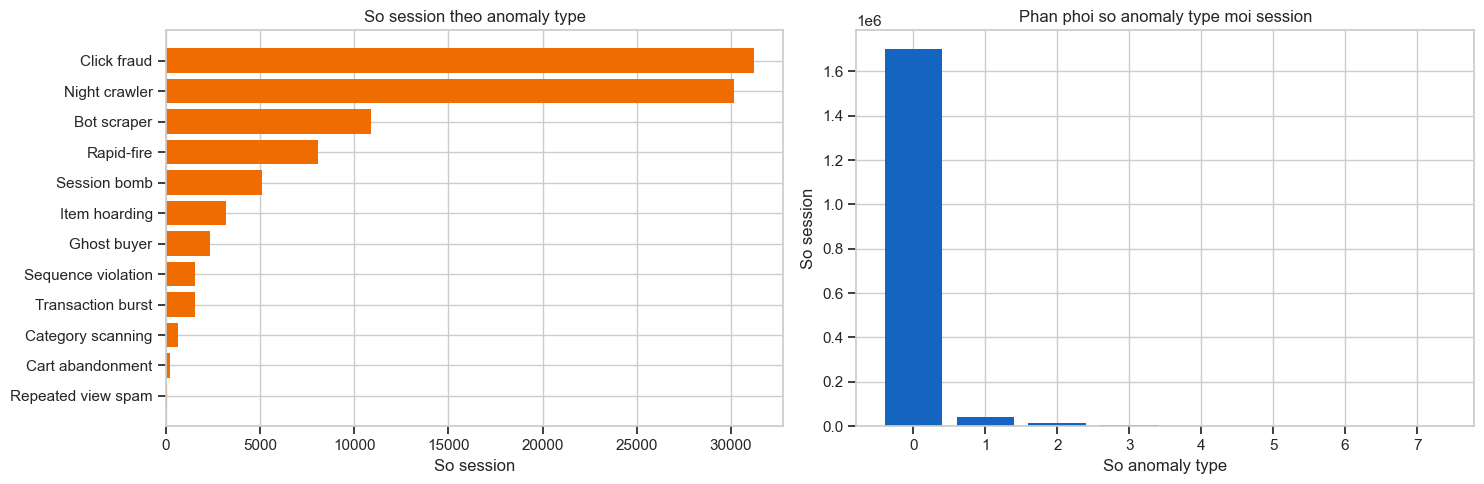

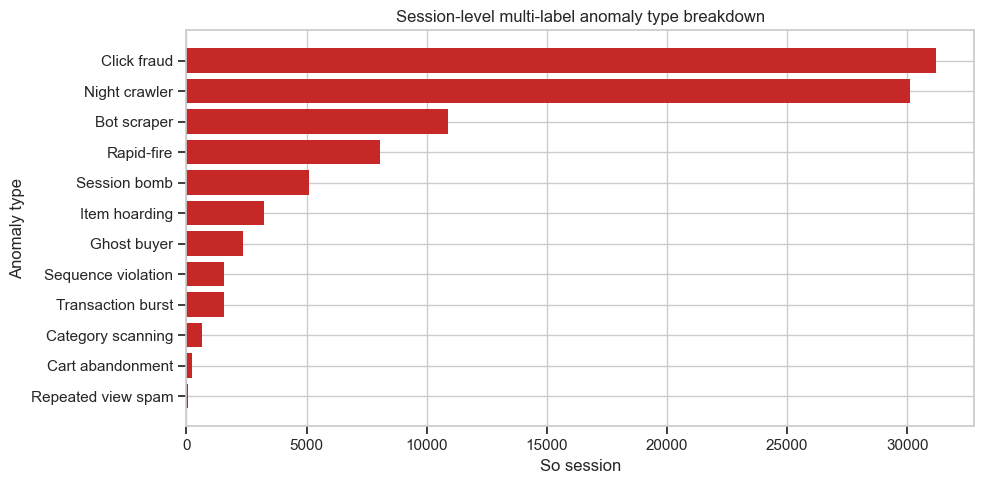

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_rules = rule_summary.sort_values('count', ascending=True)
axes[0].barh(plot_rules['anomaly_type'], plot_rules['count'], color=COLORS['warning'])
axes[0].set_title('So session theo anomaly type')
axes[0].set_xlabel('So session')

flag_distribution = anomalies['total_flags'].value_counts().sort_index()
axes[1].bar(flag_distribution.index.astype(str), flag_distribution.values, color=COLORS['primary'])
axes[1].set_title('Phan phoi so anomaly type moi session')
axes[1].set_xlabel('So anomaly type')
axes[1].set_ylabel('So session')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_rule_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
plot_type_breakdown = anomaly_type_breakdown.sort_values('count', ascending=True)
ax.barh(plot_type_breakdown['anomaly_type'], plot_type_breakdown['count'], color=COLORS['anomaly'])
ax.set_title('Session-level multi-label anomaly type breakdown')
ax.set_xlabel('So session')
ax.set_ylabel('Anomaly type')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_anomaly_type_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Kiểm tra rò rỉ nhãn theo luật nghiệp vụ

`full_feature_cols` chứa các feature tạo luật để minh họa rule-mimic. `safe_feature_cols` loại feature trực tiếp tạo nhãn và dùng cho bảng metric chính.

Audit ro ri nhan: safe feature set da loai feature truc tiep tao rule.


,rule,business_condition,rule_input_features,leaked_inputs_in_full_features,inputs_remaining_in_safe_features,n_leaked_inputs
0,BR01_bot_scraper,total_events >= 12 or events_per_minute >= 8 w...,"[total_events, events_per_minute]","[total_events, events_per_minute]",[],2
1,BR02_ghost_buyer,n_transaction > 0 and n_addtocart == 0,"[n_transaction, n_addtocart]","[n_transaction, n_addtocart]",[],2
2,BR03_click_fraud,n_view >= 6 and n_addtocart == 0 and n_transac...,"[n_view, n_addtocart, n_transaction]","[n_view, n_addtocart, n_transaction]",[],3
3,BR04_rapid_fire,rapid_fire_count >= 1 or rapid_ratio >= 0.20 w...,"[rapid_fire_count, rapid_ratio, total_events]","[rapid_fire_count, rapid_ratio, total_events]",[],3
4,BR05_night_crawler,night_ratio >= 0.75 and total_events >= 4,"[night_ratio, night_events, total_events]","[night_ratio, night_events, total_events]",[],3
5,BR06_item_hoarding,max_same_item_atc > 1,[max_same_item_atc],[max_same_item_atc],[],1
6,BR07_session_bomb,unique_items >= 12,[unique_items],[unique_items],[],1
7,BR08_sequence_violation,transaction before prior view/addtocart on sam...,[raw_event_sequence],[],[],0
8,BR09_transaction_burst,n_transaction >= 3,[n_transaction],[n_transaction],[],1
9,BR10_cart_abandonment,n_addtocart >= 10 and n_transaction == 0,"[n_addtocart, n_transaction]","[n_addtocart, n_transaction]",[],2


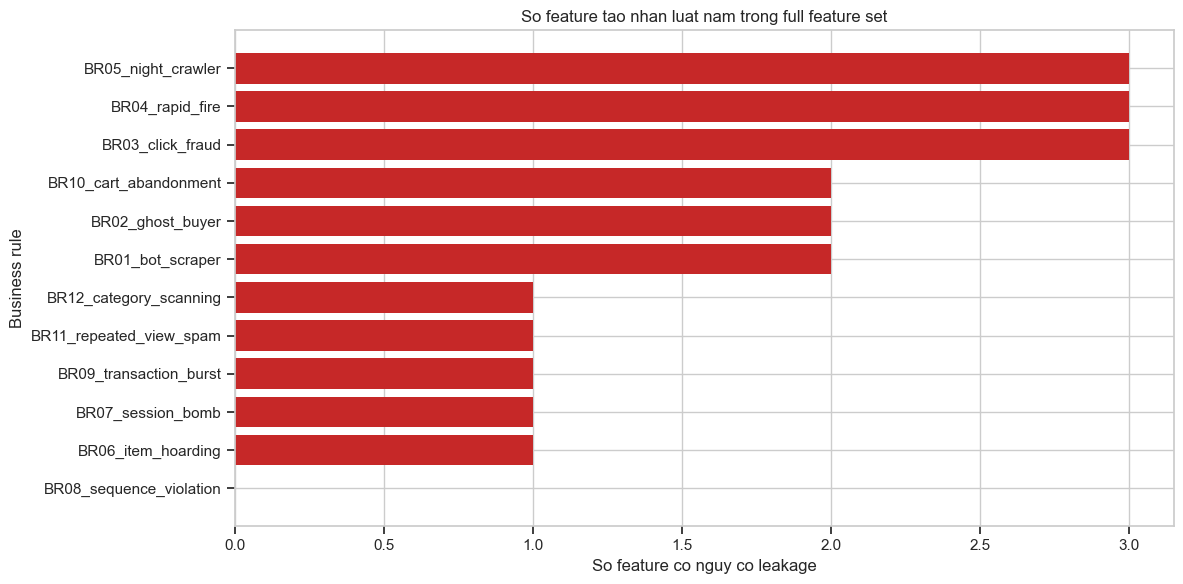

In [8]:
leakage_audit_df = pd.DataFrame([
    {'rule': 'BR01_bot_scraper', 'business_condition': 'total_events >= 12 or events_per_minute >= 8 with enough events', 'rule_input_features': ['total_events', 'events_per_minute']},
    {'rule': 'BR02_ghost_buyer', 'business_condition': 'n_transaction > 0 and n_addtocart == 0', 'rule_input_features': ['n_transaction', 'n_addtocart']},
    {'rule': 'BR03_click_fraud', 'business_condition': 'n_view >= 6 and n_addtocart == 0 and n_transaction == 0', 'rule_input_features': ['n_view', 'n_addtocart', 'n_transaction']},
    {'rule': 'BR04_rapid_fire', 'business_condition': 'rapid_fire_count >= 1 or rapid_ratio >= 0.20 with enough events', 'rule_input_features': ['rapid_fire_count', 'rapid_ratio', 'total_events']},
    {'rule': 'BR05_night_crawler', 'business_condition': 'night_ratio >= 0.75 and total_events >= 4', 'rule_input_features': ['night_ratio', 'night_events', 'total_events']},
    {'rule': 'BR06_item_hoarding', 'business_condition': 'max_same_item_atc > 1', 'rule_input_features': ['max_same_item_atc']},
    {'rule': 'BR07_session_bomb', 'business_condition': 'unique_items >= 12', 'rule_input_features': ['unique_items']},
    {'rule': 'BR08_sequence_violation', 'business_condition': 'transaction before prior view/addtocart on same session-item timeline', 'rule_input_features': ['raw_event_sequence']},
    {'rule': 'BR09_transaction_burst', 'business_condition': 'n_transaction >= 3', 'rule_input_features': ['n_transaction']},
    {'rule': 'BR10_cart_abandonment', 'business_condition': 'n_addtocart >= 10 and n_transaction == 0', 'rule_input_features': ['n_addtocart', 'n_transaction']},
    {'rule': 'BR11_repeated_view_spam', 'business_condition': 'max_same_item_view >= 20', 'rule_input_features': ['max_same_item_view']},
    {'rule': 'BR12_category_scanning', 'business_condition': 'unique_categories >= 20', 'rule_input_features': ['unique_categories']},
])

full_feature_cols = [
    'total_events', 'unique_items', 'session_duration_sec', 'duration_min', 'events_per_minute',
    'n_view', 'n_addtocart', 'n_transaction', 'active_hours', 'unique_event_types',
    'event_type_entropy', 'hour_entropy', 'min_interval_sec', 'mean_interval_sec',
    'median_interval_sec', 'std_interval_sec', 'max_interval_sec', 'rapid_fire_count',
    'night_events', 'peak_events', 'weekend_events', 'view_rate', 'atc_rate', 'buy_rate',
    'night_ratio', 'peak_ratio', 'weekend_ratio', 'rapid_ratio', 'items_per_event',
    'view_to_cart_ratio', 'cart_to_transaction_ratio', 'max_same_item_view', 'max_same_item_atc',
    'unique_categories', 'unique_parent_categories', 'session_start_hour', 'session_dayofweek',
]

safe_feature_cols = [
    'session_duration_sec',
    'active_hours',
    'unique_event_types',
    'event_type_entropy',
    'hour_entropy',
    'mean_interval_sec',
    'median_interval_sec',
    'std_interval_sec',
    'max_interval_sec',
    'peak_events',
    'weekend_events',
    'peak_ratio',
    'weekend_ratio',
    'unique_parent_categories',
    'session_dayofweek',
]

leaky_feature_set = set(full_feature_cols).difference(safe_feature_cols)
leakage_audit_df['leaked_inputs_in_full_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in leaky_feature_set]
)
leakage_audit_df['inputs_remaining_in_safe_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in safe_feature_cols]
)
leakage_audit_df['n_leaked_inputs'] = leakage_audit_df['leaked_inputs_in_full_features'].str.len()

print('Audit ro ri nhan: safe feature set da loai feature truc tiep tao rule.')
display(leakage_audit_df)

if leakage_audit_df['inputs_remaining_in_safe_features'].str.len().sum() != 0:
    raise ValueError('safe_feature_cols van chua feature truc tiep tao nhan luat')

fig, ax = plt.subplots(figsize=(12, 6))
plot_leakage = leakage_audit_df.sort_values('n_leaked_inputs', ascending=True)
ax.barh(plot_leakage['rule'], plot_leakage['n_leaked_inputs'], color=COLORS['anomaly'])
ax.set_title('So feature tao nhan luat nam trong full feature set')
ax.set_xlabel('So feature co nguy co leakage')
ax.set_ylabel('Business rule')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_leakage_audit.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Chuẩn bị dữ liệu mô hình

Bảng metric chính dùng `safe_feature_cols`; bảng phụ `full_feature_cols` chỉ để chứng minh mô hình học lại luật khi có leakage.

In [9]:
def make_clean_matrix(source_df, columns):
    X_matrix = source_df[columns].replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    if X_matrix.isna().any().any():
        raise ValueError('X van con NaN sau tien xu ly')
    if not np.isfinite(X_matrix.to_numpy()).all():
        raise ValueError('X van con inf sau tien xu ly')
    return X_matrix

X_full = make_clean_matrix(anomalies, full_feature_cols)
X_safe = make_clean_matrix(anomalies, safe_feature_cols)
y = anomalies['is_anomaly_rule'].astype(int)

if y.nunique() != 2:
    raise ValueError('Nhan is_anomaly_rule phai co du 2 lop')

safe_scaler = RobustScaler()
X_safe_scaled = safe_scaler.fit_transform(X_safe).astype('float32')

full_scaler = RobustScaler()
X_full_scaled = full_scaler.fit_transform(X_full).astype('float32')

all_indices = np.arange(len(y))
if MAX_SUPERVISED_ROWS is not None and len(y) > MAX_SUPERVISED_ROWS:
    supervised_indices, _ = train_test_split(
        all_indices,
        train_size=MAX_SUPERVISED_ROWS,
        random_state=RANDOM_STATE,
        stratify=y,
    )
else:
    supervised_indices = all_indices

train_idx, test_idx = train_test_split(
    supervised_indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y.iloc[supervised_indices],
)

X_safe_train = X_safe.iloc[train_idx]
X_safe_test = X_safe.iloc[test_idx]
X_full_train = X_full.iloc[train_idx]
X_full_test = X_full.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f'Toan bo session profile: {len(X_safe):,} dong')
print(f'Mau supervised training/evaluation: {len(supervised_indices):,} dong')
print(f'Train: {len(train_idx):,}; Test: {len(test_idx):,}')
print(f'Ty le anomaly trong toan bo session: {y.mean() * 100:.2f}%')
print(f'Ty le anomaly trong mau supervised: {y.iloc[supervised_indices].mean() * 100:.2f}%')
print(f'So safe features: {len(safe_feature_cols)}; So full features: {len(full_feature_cols)}')

Toan bo session profile: 1,761,675 dong
Mau supervised training/evaluation: 300,000 dong
Train: 240,000; Test: 60,000
Ty le anomaly trong toan bo session: 3.51%
Ty le anomaly trong mau supervised: 3.51%
So safe features: 15; So full features: 37


In [10]:
evaluation_records = []
prediction_sets = {}


def add_evaluation(model_name, feature_set, evaluation_type, y_true, y_pred, y_score=None, store_confusion=True):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    record = {
        'model': model_name,
        'feature_set': feature_set,
        'evaluation_type': evaluation_type,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': np.nan,
        'pr_auc': np.nan,
        'support_anomaly': int(y_true.sum()),
        'predicted_anomaly': int(y_pred.sum()),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        try:
            record['roc_auc'] = roc_auc_score(y_true, y_score)
        except ValueError:
            record['roc_auc'] = np.nan
        try:
            record['pr_auc'] = average_precision_score(y_true, y_score)
        except ValueError:
            record['pr_auc'] = np.nan

    evaluation_records.append(record)
    key = f'{model_name} ({feature_set})'
    if store_confusion:
        prediction_sets[key] = {'y_true': y_true, 'y_pred': y_pred, 'evaluation_type': evaluation_type}

    print(f'\n{model_name} - {feature_set} - {evaluation_type}')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], zero_division=0))

## 7. Baseline và mô hình supervised trên safe feature set

In [11]:
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_model.fit(X_safe_train, y_train)
dummy_test_pred = dummy_model.predict(X_safe_test)
dummy_test_score = dummy_model.predict_proba(X_safe_test)[:, 1]
add_evaluation('Dummy baseline', 'safe_features', 'Baseline vs session pseudo-label', y_test, dummy_test_pred, dummy_test_score, store_confusion=False)


Dummy baseline - safe_features - Baseline vs session pseudo-label
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97     57894
     Anomaly       0.05      0.05      0.05      2106

    accuracy                           0.93     60000
   macro avg       0.51      0.51      0.51     60000
weighted avg       0.93      0.93      0.93     60000



### Người 1 - XGBoost

In [12]:
def make_xgb_model(n_estimators=120, scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=n_estimators,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

xgb_safe_model = make_xgb_model(n_estimators=120, scale_pos_weight=scale_pos_weight)
xgb_safe_model.fit(X_safe_train, y_train)
xgb_safe_score = xgb_safe_model.predict_proba(X_safe_test)[:, 1]
xgb_safe_pred = (xgb_safe_score >= 0.5).astype(int)
add_evaluation('XGBoost', 'safe_features', 'Main supervised vs session pseudo-label', y_test, xgb_safe_pred, xgb_safe_score)

anomalies['xgboost_score'] = xgb_safe_model.predict_proba(X_safe)[:, 1]
anomalies['xgboost_pred'] = (anomalies['xgboost_score'] >= 0.5).astype(int)


XGBoost - safe_features - Main supervised vs session pseudo-label
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     57894
     Anomaly       0.54      0.97      0.70      2106

    accuracy                           0.97     60000
   macro avg       0.77      0.97      0.84     60000
weighted avg       0.98      0.97      0.97     60000



### Người 2 - Decision Tree


Decision Tree - safe_features - Main supervised vs session pseudo-label
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     57894
     Anomaly       0.49      0.97      0.66      2106

    accuracy                           0.96     60000
   macro avg       0.75      0.97      0.82     60000
weighted avg       0.98      0.96      0.97     60000



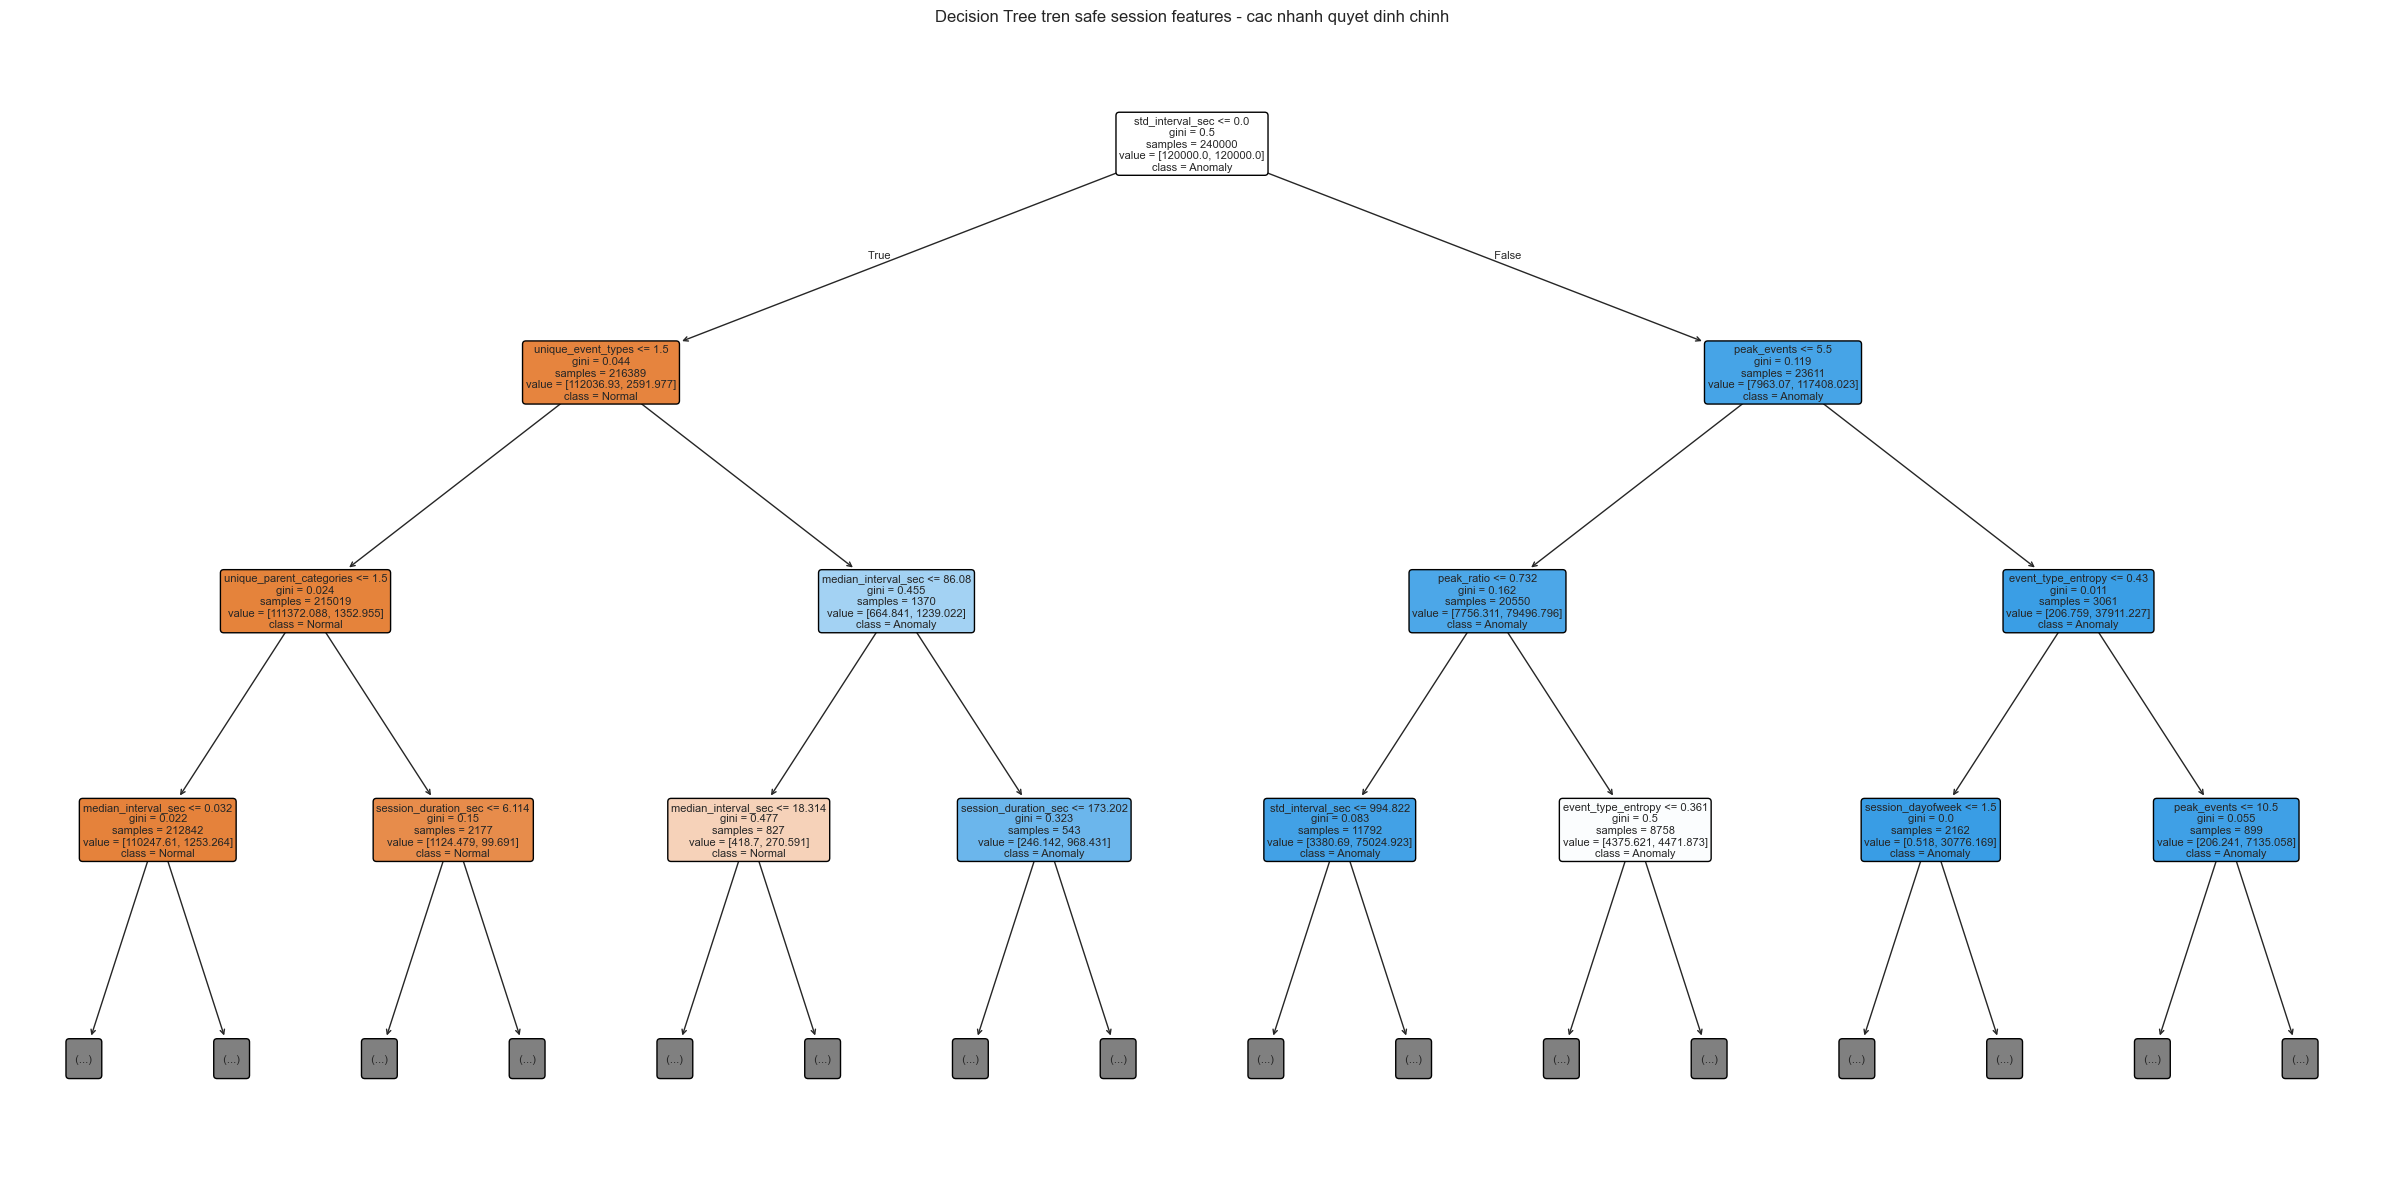

In [13]:
dt_safe_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)

dt_safe_model.fit(X_safe_train, y_train)
dt_safe_score = dt_safe_model.predict_proba(X_safe_test)[:, 1]
dt_safe_pred = (dt_safe_score >= 0.5).astype(int)
add_evaluation('Decision Tree', 'safe_features', 'Main supervised vs session pseudo-label', y_test, dt_safe_pred, dt_safe_score)

anomalies['decision_tree_score'] = dt_safe_model.predict_proba(X_safe)[:, 1]
anomalies['decision_tree_pred'] = (anomalies['decision_tree_score'] >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    dt_safe_model,
    feature_names=safe_feature_cols,
    class_names=['Normal', 'Anomaly'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title('Decision Tree tren safe session features - cac nhanh quyet dinh chinh')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_decision_tree.png', dpi=160, bbox_inches='tight')
plt.show()

### Người 3 - Random Forest

In [14]:
rf_safe_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_safe_model.fit(X_safe_train, y_train)
rf_safe_score = rf_safe_model.predict_proba(X_safe_test)[:, 1]
rf_safe_pred = (rf_safe_score >= 0.5).astype(int)
add_evaluation('Random Forest', 'safe_features', 'Main supervised vs session pseudo-label', y_test, rf_safe_pred, rf_safe_score)

anomalies['random_forest_score'] = rf_safe_model.predict_proba(X_safe)[:, 1]
anomalies['random_forest_pred'] = (anomalies['random_forest_score'] >= 0.5).astype(int)


Random Forest - safe_features - Main supervised vs session pseudo-label
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     57894
     Anomaly       0.48      0.97      0.64      2106

    accuracy                           0.96     60000
   macro avg       0.74      0.97      0.81     60000
weighted avg       0.98      0.96      0.97     60000



## 8. Bảng phụ: mô hình học lại luật bằng full feature set

Phần này cố tình giữ các feature tạo luật để chứng minh vì sao metric có thể quá đẹp khi bị leakage.

In [15]:
xgb_full_model = make_xgb_model(n_estimators=120, scale_pos_weight=scale_pos_weight)
xgb_full_model.fit(X_full_train, y_train)
xgb_full_score = xgb_full_model.predict_proba(X_full_test)[:, 1]
xgb_full_pred = (xgb_full_score >= 0.5).astype(int)
add_evaluation('XGBoost', 'full_features', 'Rule-mimic / agreement with session business rules', y_test, xgb_full_pred, xgb_full_score, store_confusion=False)

dt_full_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=100, class_weight='balanced', random_state=RANDOM_STATE)
dt_full_model.fit(X_full_train, y_train)
dt_full_score = dt_full_model.predict_proba(X_full_test)[:, 1]
dt_full_pred = (dt_full_score >= 0.5).astype(int)
add_evaluation('Decision Tree', 'full_features', 'Rule-mimic / agreement with session business rules', y_test, dt_full_pred, dt_full_score, store_confusion=False)

rf_full_model = RandomForestClassifier(n_estimators=120, max_depth=10, min_samples_leaf=50, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
rf_full_model.fit(X_full_train, y_train)
rf_full_score = rf_full_model.predict_proba(X_full_test)[:, 1]
rf_full_pred = (rf_full_score >= 0.5).astype(int)
add_evaluation('Random Forest', 'full_features', 'Rule-mimic / agreement with session business rules', y_test, rf_full_pred, rf_full_score, store_confusion=False)


XGBoost - full_features - Rule-mimic / agreement with session business rules
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     57894
     Anomaly       1.00      1.00      1.00      2106

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000




Decision Tree - full_features - Rule-mimic / agreement with session business rules
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     57894
     Anomaly       0.81      1.00      0.89      2106

    accuracy                           0.99     60000
   macro avg       0.90      1.00      0.95     60000
weighted avg       0.99      0.99      0.99     60000




Random Forest - full_features - Rule-mimic / agreement with session business rules
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     57894
     Anomaly       0.89      1.00      0.94      2106

    accuracy                           1.00     60000
   macro avg       0.95      1.00      0.97     60000
weighted avg       1.00      1.00      1.00     60000



## 9. Shuffle-label sanity check

In [16]:
rng = np.random.default_rng(RANDOM_STATE)
y_train_shuffled = pd.Series(rng.permutation(y_train.to_numpy()), index=y_train.index)
shuffle_pos = int((y_train_shuffled == 1).sum())
shuffle_neg = int((y_train_shuffled == 0).sum())
shuffle_scale_pos_weight = shuffle_neg / max(shuffle_pos, 1)

xgb_shuffle_model = make_xgb_model(n_estimators=60, scale_pos_weight=shuffle_scale_pos_weight)
xgb_shuffle_model.fit(X_safe_train, y_train_shuffled)
shuffle_score = xgb_shuffle_model.predict_proba(X_safe_test)[:, 1]
shuffle_pred = (shuffle_score >= 0.5).astype(int)
add_evaluation('XGBoost shuffled-label sanity check', 'safe_features', 'Sanity check: shuffled labels should fail', y_test, shuffle_pred, shuffle_score, store_confusion=False)

shuffle_pr_auc = average_precision_score(y_test, shuffle_score)
print(f'PR-AUC shuffled-label: {shuffle_pr_auc:.4f}; prevalence anomaly test: {y_test.mean():.4f}')
if shuffle_pr_auc > max(0.20, y_test.mean() * 10):
    print('Canh bao: shuffle-label PR-AUC cao bat thuong, can audit lai pipeline.')
else:
    print('Sanity check dat: model khong con dep khi nhan bi trao ngau nhien.')


XGBoost shuffled-label sanity check - safe_features - Sanity check: shuffled labels should fail
              precision    recall  f1-score   support

      Normal       0.94      0.42      0.58     57894
     Anomaly       0.01      0.24      0.03      2106

    accuracy                           0.41     60000
   macro avg       0.48      0.33      0.30     60000
weighted avg       0.91      0.41      0.56     60000

PR-AUC shuffled-label: 0.0532; prevalence anomaly test: 0.0351
Sanity check dat: model khong con dep khi nhan bi trao ngau nhien.


## 10. Feature importance trên safe session feature set

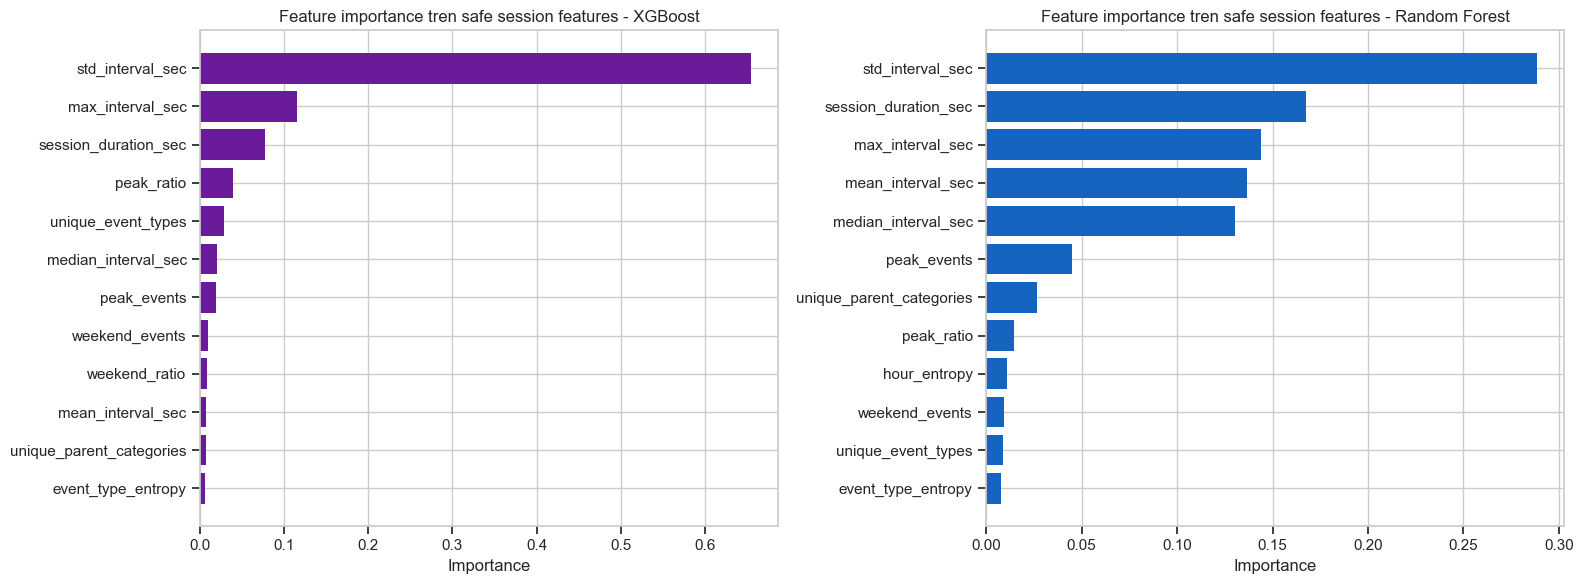

,feature,importance,model
0,std_interval_sec,0.654072,XGBoost
1,max_interval_sec,0.115043,XGBoost
2,session_duration_sec,0.076915,XGBoost
3,peak_ratio,0.039174,XGBoost
4,unique_event_types,0.029267,XGBoost
5,median_interval_sec,0.020211,XGBoost
6,peak_events,0.018710,XGBoost
7,weekend_events,0.009656,XGBoost
8,weekend_ratio,0.008542,XGBoost
9,mean_interval_sec,0.007683,XGBoost


In [17]:
def top_importance_frame(model, feature_names, name, top_n=12):
    frame = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_, 'model': name})
    return frame.sort_values('importance', ascending=False).head(top_n)

importance_df = pd.concat([
    top_importance_frame(xgb_safe_model, safe_feature_cols, 'XGBoost'),
    top_importance_frame(rf_safe_model, safe_feature_cols, 'Random Forest'),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model_name in zip(axes, ['XGBoost', 'Random Forest']):
    subset = importance_df[importance_df['model'] == model_name].sort_values('importance', ascending=True)
    ax.barh(subset['feature'], subset['importance'], color=COLORS['secondary'] if model_name == 'XGBoost' else COLORS['primary'])
    ax.set_title(f'Feature importance tren safe session features - {model_name}')
    ax.set_xlabel('Importance')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

display(importance_df)

## 11. Người 4 - K-Means

In [18]:
if KMEANS_TRAIN_ROWS is not None and len(X_safe_scaled) > KMEANS_TRAIN_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    kmeans_train_indices = rng.choice(len(X_safe_scaled), size=KMEANS_TRAIN_ROWS, replace=False)
else:
    kmeans_train_indices = np.arange(len(X_safe_scaled))

kmeans_model = KMeans(n_clusters=5, n_init=10, max_iter=100, random_state=RANDOM_STATE)
kmeans_model.fit(X_safe_scaled[kmeans_train_indices])

kmeans_cluster = kmeans_model.predict(X_safe_scaled)
kmeans_distance = kmeans_model.transform(X_safe_scaled).min(axis=1)
kmeans_threshold = np.quantile(kmeans_distance, 0.95)
kmeans_pred = (kmeans_distance >= kmeans_threshold).astype(int)

anomalies['kmeans_cluster'] = kmeans_cluster
anomalies['kmeans_distance'] = kmeans_distance
anomalies['kmeans_pred'] = kmeans_pred

add_evaluation('K-Means', 'safe_features', 'Unsupervised overlap with session pseudo-label', y, kmeans_pred, kmeans_distance)

cluster_summary = anomalies.groupby('kmeans_cluster').agg(
    sessions=('visitorid', 'size'),
    rule_anomaly_rate=('is_anomaly_rule', 'mean'),
    avg_total_events=('total_events', 'mean'),
    avg_duration_sec=('session_duration_sec', 'mean'),
    avg_event_entropy=('event_type_entropy', 'mean'),
    avg_hour_entropy=('hour_entropy', 'mean'),
    avg_distance=('kmeans_distance', 'mean'),
).reset_index()
cluster_summary['rule_anomaly_rate'] = cluster_summary['rule_anomaly_rate'] * 100
print(f'Nguong anomaly theo khoang cach K-Means top 5%: {kmeans_threshold:.4f}')
display(cluster_summary)


K-Means - safe_features - Unsupervised overlap with session pseudo-label


              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97   1699826
     Anomaly       0.33      0.48      0.39     61849

    accuracy                           0.95   1761675
   macro avg       0.66      0.72      0.68   1761675
weighted avg       0.96      0.95      0.95   1761675

Nguong anomaly theo khoang cach K-Means top 5%: 412.6671


,kmeans_cluster,sessions,rule_anomaly_rate,avg_total_events,avg_duration_sec,avg_event_entropy,avg_hour_entropy,avg_distance
0,0,1611727,1.307107,1.245061,14.385514,0.011669,0.003629,39.764900
1,1,42624,22.165916,4.111275,1526.244141,0.123172,0.376846,894.174438
2,2,684,100.000000,73.219298,15119.178711,0.634158,2.096450,4067.013428
3,3,100274,24.949638,4.098101,603.743347,0.143347,0.147623,413.403809
4,4,6366,88.469997,17.701697,4128.701660,0.339478,0.834966,1265.135376


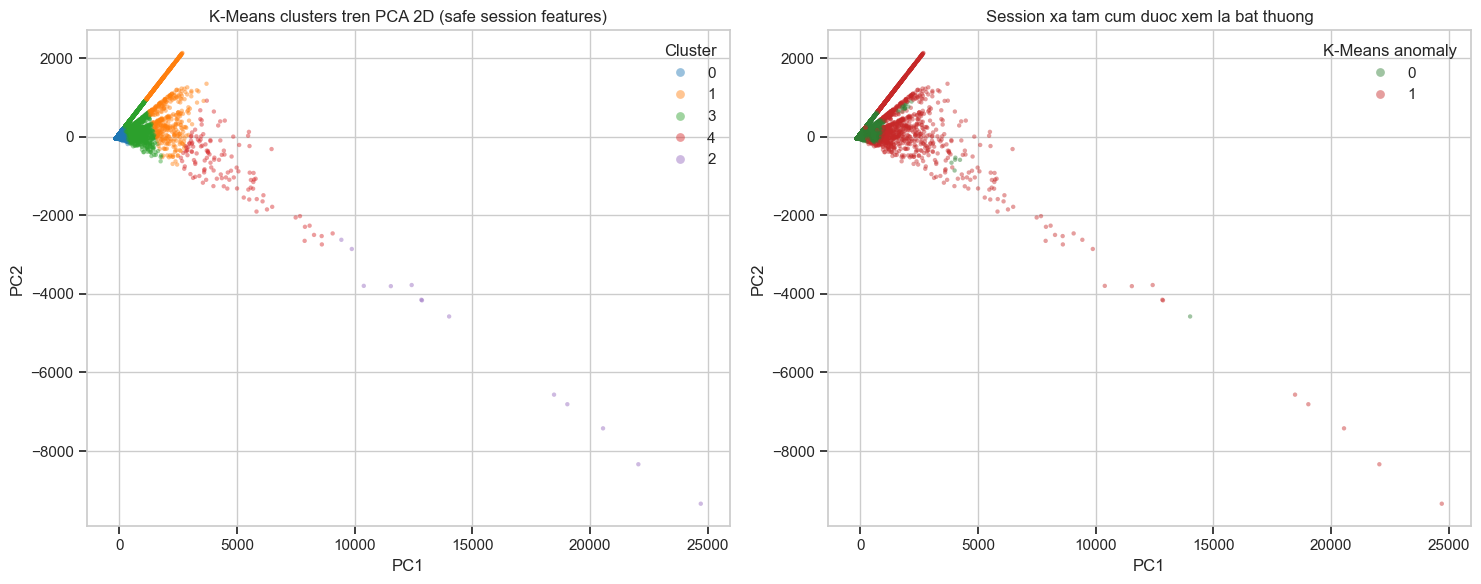

In [19]:
if PLOT_SAMPLE_ROWS is not None and len(X_safe_scaled) > PLOT_SAMPLE_ROWS:
    plot_indices, _ = train_test_split(
        np.arange(len(X_safe_scaled)),
        train_size=PLOT_SAMPLE_ROWS,
        random_state=RANDOM_STATE,
        stratify=y,
    )
else:
    plot_indices = np.arange(len(X_safe_scaled))

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_plot_pca = pca.fit_transform(X_safe_scaled[plot_indices])
plot_frame = pd.DataFrame({
    'PC1': X_plot_pca[:, 0],
    'PC2': X_plot_pca[:, 1],
    'cluster': anomalies['kmeans_cluster'].iloc[plot_indices].astype(str).values,
    'kmeans_anomaly': anomalies['kmeans_pred'].iloc[plot_indices].values,
    'rule_anomaly': y.iloc[plot_indices].values,
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=plot_frame, x='PC1', y='PC2', hue='cluster', s=10, alpha=0.45, linewidth=0, palette='tab10', ax=axes[0])
axes[0].set_title('K-Means clusters tren PCA 2D (safe session features)')
axes[0].legend(title='Cluster', markerscale=2)

sns.scatterplot(data=plot_frame, x='PC1', y='PC2', hue='kmeans_anomaly', s=10, alpha=0.45, linewidth=0, palette={0: COLORS['normal'], 1: COLORS['anomaly']}, ax=axes[1])
axes[1].set_title('Session xa tam cum duoc xem la bat thuong')
axes[1].legend(title='K-Means anomaly', markerscale=2)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_kmeans_pca.png', dpi=160, bbox_inches='tight')
plt.show()

## 12. Người 5 - Isolation Forest


Isolation Forest - safe_features - Unsupervised overlap with session pseudo-label


              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97   1699826
     Anomaly       0.33      0.47      0.38     61849

    accuracy                           0.95   1761675
   macro avg       0.65      0.72      0.68   1761675
weighted avg       0.96      0.95      0.95   1761675



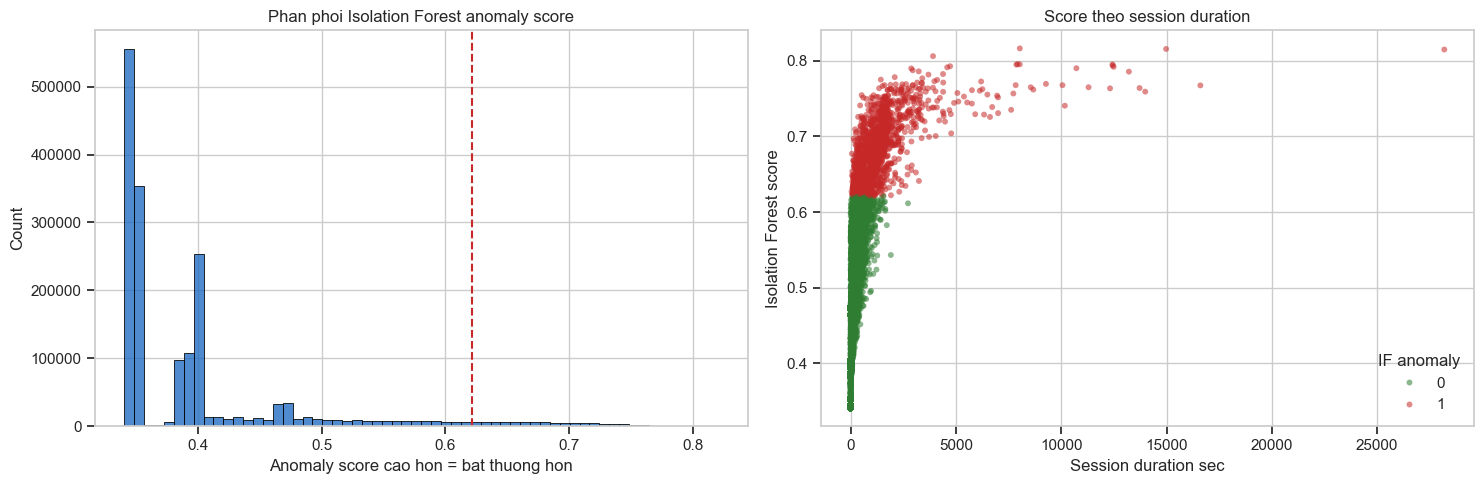

In [20]:
if IFOREST_TRAIN_ROWS is not None and len(X_safe_scaled) > IFOREST_TRAIN_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    iforest_train_indices = rng.choice(len(X_safe_scaled), size=IFOREST_TRAIN_ROWS, replace=False)
else:
    iforest_train_indices = np.arange(len(X_safe_scaled))

iforest_model = IsolationForest(n_estimators=150, contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1)
iforest_model.fit(X_safe_scaled[iforest_train_indices])

iforest_raw_pred = iforest_model.predict(X_safe_scaled)
iforest_score = -iforest_model.score_samples(X_safe_scaled)
iforest_pred = (iforest_raw_pred == -1).astype(int)

anomalies['isolation_forest_score'] = iforest_score
anomalies['isolation_forest_pred'] = iforest_pred

add_evaluation('Isolation Forest', 'safe_features', 'Unsupervised overlap with session pseudo-label', y, iforest_pred, iforest_score)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(anomalies['isolation_forest_score'], bins=60, color=COLORS['primary'], ax=axes[0])
axes[0].axvline(anomalies.loc[anomalies['isolation_forest_pred'] == 1, 'isolation_forest_score'].min(), color=COLORS['anomaly'], linestyle='--')
axes[0].set_title('Phan phoi Isolation Forest anomaly score')
axes[0].set_xlabel('Anomaly score cao hon = bat thuong hon')

score_sample = anomalies.sample(min(PLOT_SAMPLE_ROWS, len(anomalies)), random_state=RANDOM_STATE)
sns.scatterplot(data=score_sample, x='session_duration_sec', y='isolation_forest_score', hue='isolation_forest_pred', palette={0: COLORS['normal'], 1: COLORS['anomaly']}, alpha=0.55, linewidth=0, s=18, ax=axes[1])
axes[1].set_title('Score theo session duration')
axes[1].set_xlabel('Session duration sec')
axes[1].set_ylabel('Isolation Forest score')
axes[1].legend(title='IF anomaly')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_isolation_scores.png', dpi=160, bbox_inches='tight')
plt.show()

## 13. So sánh 5 thuật toán

Bảng chính dùng `safe_features`. Với supervised models, metric là mức độ khớp với session pseudo-label sau khi giảm leakage. Với unsupervised models, metric là overlap tham khảo với session pseudo-label.

Bang metric chinh tren safe session features / pseudo-label overlap:


,model,feature_set,evaluation_type,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
0,Dummy baseline,safe_features,Baseline vs session pseudo-label,0.9332,0.0454,0.0451,0.0453,0.5053,0.0356,2106,2091
1,XGBoost,safe_features,Main supervised vs session pseudo-label,0.9702,0.5420,0.9734,0.6963,0.9913,0.9219,2106,3782
2,Decision Tree,safe_features,Main supervised vs session pseudo-label,0.9642,0.4948,0.9720,0.6558,0.9835,0.7310,2106,4137
3,Random Forest,safe_features,Main supervised vs session pseudo-label,0.9622,0.4812,0.9748,0.6444,0.9899,0.8954,2106,4266
8,K-Means,safe_features,Unsupervised overlap with session pseudo-label,0.9483,0.3343,0.4761,0.3928,0.9260,0.3660,61849,88084
9,Isolation Forest,safe_features,Unsupervised overlap with session pseudo-label,0.9475,0.3261,0.4657,0.3836,0.9383,0.3555,61849,88325


Bang phu: full features hoc lai luat session:


,model,feature_set,evaluation_type,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
4,XGBoost,full_features,Rule-mimic / agreement with session business r...,0.9999,0.9962,1.0,0.9981,1.0000,1.0000,2106,2114
5,Decision Tree,full_features,Rule-mimic / agreement with session business r...,0.9917,0.8094,1.0,0.8946,0.9999,0.9967,2106,2602
6,Random Forest,full_features,Rule-mimic / agreement with session business r...,0.9958,0.8924,1.0,0.9431,0.9999,0.9977,2106,2360


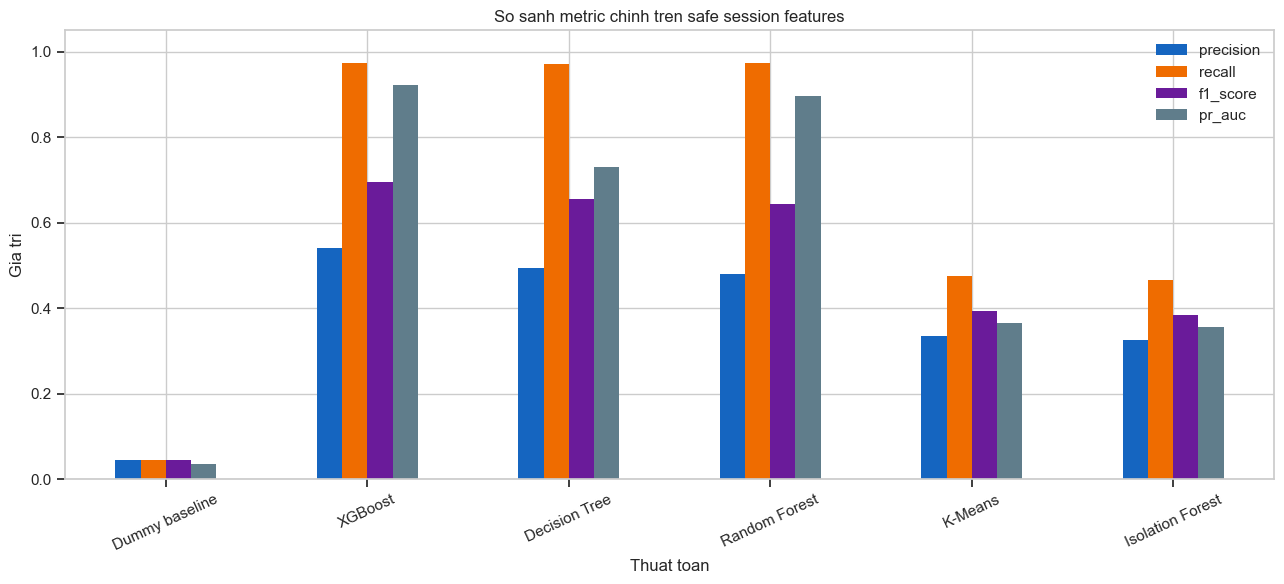

In [21]:
metrics_df = pd.DataFrame(evaluation_records)
metric_cols = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']
metrics_df[metric_cols] = metrics_df[metric_cols].round(4)

main_metrics_df = metrics_df[
    metrics_df['evaluation_type'].isin([
        'Baseline vs session pseudo-label',
        'Main supervised vs session pseudo-label',
        'Unsupervised overlap with session pseudo-label',
    ])
].copy()
rule_mimic_metrics_df = metrics_df[
    metrics_df['evaluation_type'] == 'Rule-mimic / agreement with session business rules'
].copy()

print('Bang metric chinh tren safe session features / pseudo-label overlap:')
display(main_metrics_df)
print('Bang phu: full features hoc lai luat session:')
display(rule_mimic_metrics_df)

fig, ax = plt.subplots(figsize=(13, 6))
plot_metrics = main_metrics_df.set_index('model')[['precision', 'recall', 'f1_score', 'pr_auc']]
plot_metrics.plot(kind='bar', ax=ax, color=[COLORS['primary'], COLORS['warning'], COLORS['secondary'], COLORS['muted']])
ax.set_title('So sanh metric chinh tren safe session features')
ax.set_xlabel('Thuat toan')
ax.set_ylabel('Gia tri')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

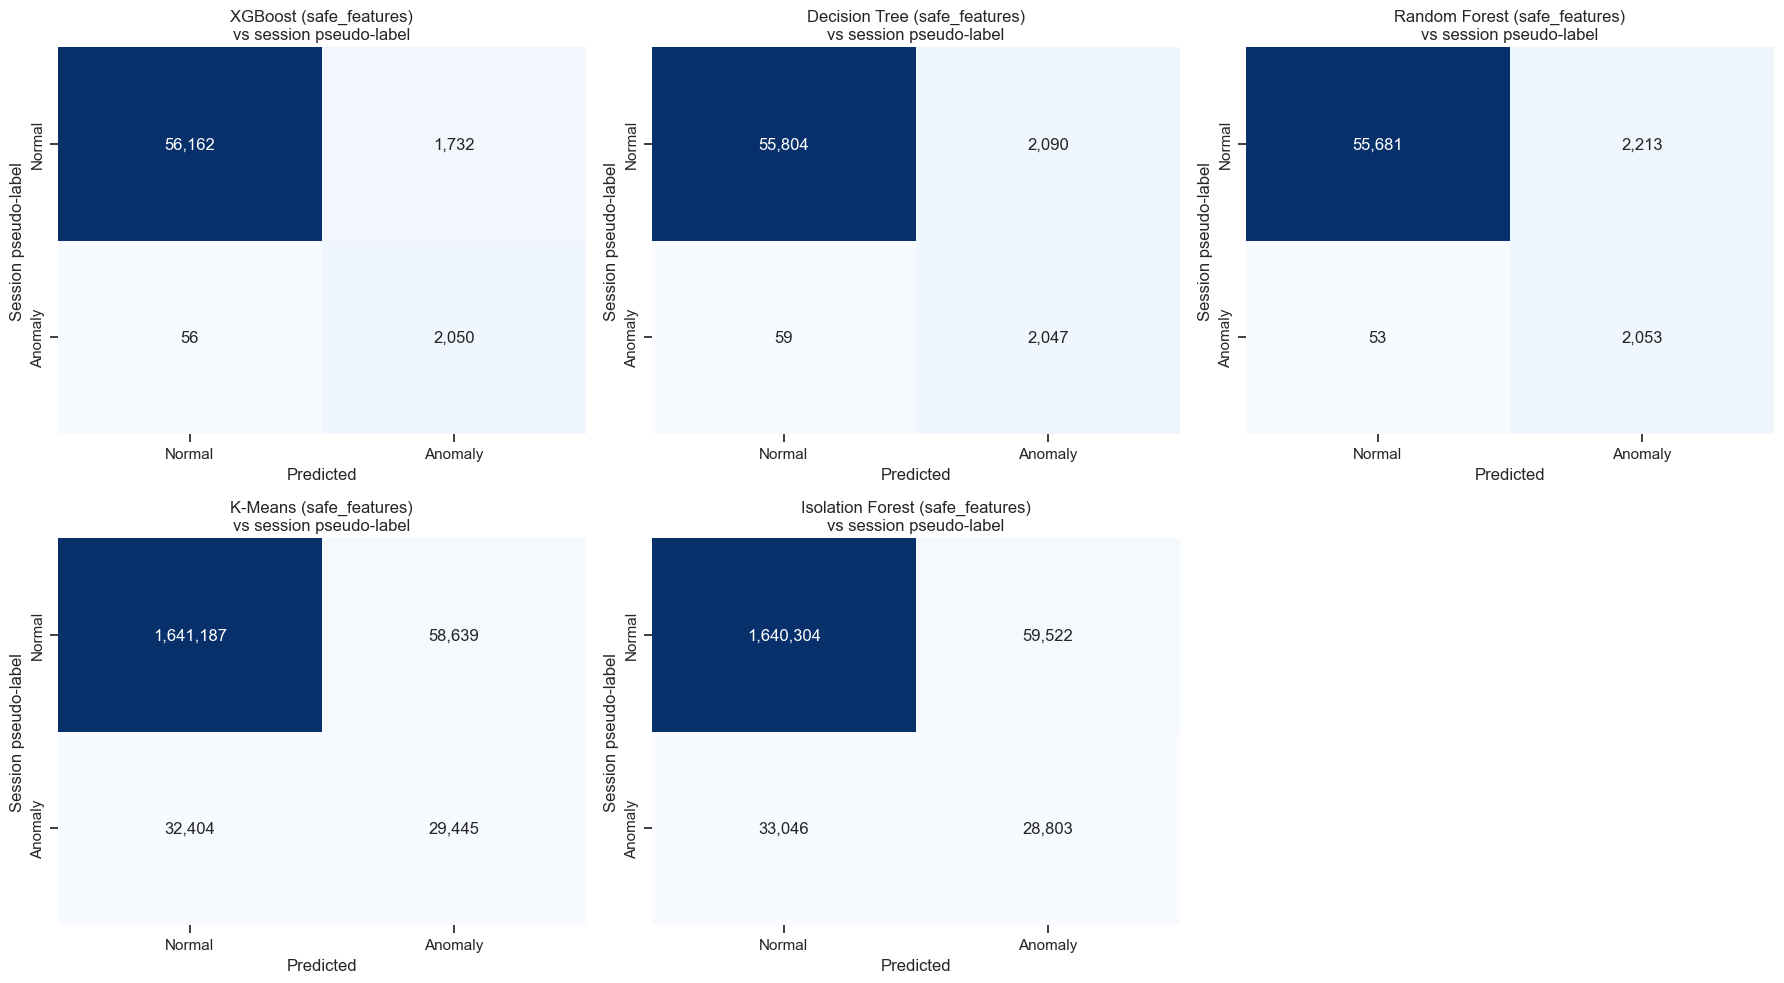

In [22]:
confusion_items = {
    key: value
    for key, value in prediction_sets.items()
    if key in [
        'XGBoost (safe_features)',
        'Decision Tree (safe_features)',
        'Random Forest (safe_features)',
        'K-Means (safe_features)',
        'Isolation Forest (safe_features)',
    ]
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (model_name, values) in zip(axes, confusion_items.items()):
    cm = confusion_matrix(values['y_true'], values['y_pred'], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'], cbar=False, ax=ax)
    ax.set_title(f'{model_name}\nvs session pseudo-label')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Session pseudo-label')

for ax in axes[len(confusion_items):]:
    ax.axis('off')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()

## 14. Session anomaly report và export

`session_anomaly_tags.csv` là bảng tag rule-level cho mọi session. `session_anomaly_report.csv` là bảng tổng hợp các session bị rule hoặc model đánh dấu.

In [23]:
model_pred_cols = ['xgboost_pred', 'decision_tree_pred', 'random_forest_pred', 'kmeans_pred', 'isolation_forest_pred']
anomalies['model_vote_count'] = anomalies[model_pred_cols].sum(axis=1)
anomalies['is_rule_anomaly'] = anomalies['is_anomaly_rule']
anomalies['is_model_anomaly'] = (anomalies['model_vote_count'] > 0).astype(int)
anomalies['is_anomaly_final'] = ((anomalies['is_rule_anomaly'] == 1) | (anomalies['is_model_anomaly'] == 1)).astype(int)
anomalies['rule_anomaly_types'] = anomalies['anomaly_types']
anomalies['final_anomaly_reason'] = np.select(
    [
        (anomalies['is_rule_anomaly'] == 1) & (anomalies['is_model_anomaly'] == 1),
        anomalies['is_rule_anomaly'] == 1,
        anomalies['is_model_anomaly'] == 1,
    ],
    ['Business rules + ML models', 'Business rules', 'ML model-only suspicious'],
    default='Normal',
)

score_99 = anomalies['isolation_forest_score'].quantile(0.99)

def classify_severity(row):
    if row['total_flags'] >= 3 or row['model_vote_count'] >= 4 or row['isolation_forest_score'] >= score_99:
        return 'CRITICAL'
    if row['total_flags'] >= 2 or row['model_vote_count'] >= 2:
        return 'HIGH'
    if row['total_flags'] == 1 or row['model_vote_count'] == 1:
        return 'MEDIUM'
    return 'LOW'

anomalies['severity'] = anomalies.apply(classify_severity, axis=1)
severity_order = {'CRITICAL': 3, 'HIGH': 2, 'MEDIUM': 1, 'LOW': 0}
anomalies['severity_rank'] = anomalies['severity'].map(severity_order)

if not (anomalies['anomaly_type_count'] == anomalies['total_flags']).all():
    raise ValueError('anomaly_type_count phai bang total_flags truoc khi export')
if not (anomalies.loc[anomalies['is_rule_anomaly'] == 0, 'rule_anomaly_types'] == 'Normal').all():
    raise ValueError('Normal session phai co rule_anomaly_types = Normal truoc khi export')

session_anomaly_tags = anomalies[
    ['visitorid', 'session_number', 'is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols
].reset_index()

report_cols = [
    'visitorid', 'session_number', 'session_start', 'session_end',
    'is_anomaly_final', 'final_anomaly_reason', 'is_rule_anomaly', 'rule_anomaly_types',
    'is_model_anomaly', 'model_vote_count', 'severity', 'anomaly_type_count', 'total_flags',
    'total_events', 'unique_items', 'session_duration_sec', 'events_per_minute',
    'event_type_entropy', 'hour_entropy', 'xgboost_score', 'decision_tree_score',
    'random_forest_score', 'kmeans_distance', 'isolation_forest_score',
] + model_pred_cols + flag_cols

session_anomaly_report = (
    anomalies[anomalies['is_anomaly_final'] == 1]
    .sort_values(['severity_rank', 'model_vote_count', 'total_flags', 'isolation_forest_score'], ascending=[False, False, False, False])
    [report_cols]
    .reset_index()
)

session_anomaly_tags.to_csv(OUTPUT_DIR / 'session_anomaly_tags.csv', index=False)
session_anomaly_report.to_csv(OUTPUT_DIR / 'session_anomaly_report.csv', index=False)
metrics_df.to_csv(OUTPUT_DIR / 'group_model_metrics.csv', index=False)
leakage_audit_df.to_csv(OUTPUT_DIR / 'group_leakage_audit.csv', index=False)
anomaly_type_breakdown.to_csv(OUTPUT_DIR / 'group_anomaly_type_breakdown.csv', index=False)

print(f'So session trong anomaly report: {len(session_anomaly_report):,}')
print('Da export: session_anomaly_tags.csv')
print('Da export: session_anomaly_report.csv')
print('Da export: group_model_metrics.csv')
print('Da export: group_leakage_audit.csv')
print('Da export: group_anomaly_type_breakdown.csv')
print('\nVi du session anomaly report:')
display(session_anomaly_report.head(15))

So session trong anomaly report: 183,930
Da export: session_anomaly_tags.csv
Da export: session_anomaly_report.csv
Da export: group_model_metrics.csv
Da export: group_leakage_audit.csv
Da export: group_anomaly_type_breakdown.csv

Vi du session anomaly report:


,session_id,visitorid,session_number,session_start,session_end,is_anomaly_final,final_anomaly_reason,is_rule_anomaly,rule_anomaly_types,is_model_anomaly,...,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation,flag_BR09_transaction_burst,flag_BR10_cart_abandonment,flag_BR11_repeated_view_spam,flag_BR12_category_scanning
0,530559_S107,530559,107,2015-07-25 15:28:17.422,2015-07-26 02:17:25.589,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
1,286616_S40,286616,40,2015-05-30 21:25:11.588,2015-05-30 23:44:29.087,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
2,1376763_S2,1376763,2,2015-07-20 19:49:40.822,2015-07-21 02:07:07.124,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
3,1150086_S70,1150086,70,2015-07-10 15:19:05.296,2015-07-10 19:10:50.966,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
4,994820_S36,994820,36,2015-09-07 15:45:41.528,2015-09-07 21:22:24.787,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
5,890980_S18,890980,18,2015-07-20 19:26:39.701,2015-07-21 00:48:45.945,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
6,152963_S48,152963,48,2015-08-20 19:05:27.399,2015-08-20 22:44:21.935,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
7,582933_S3,582933,3,2015-07-20 14:47:02.477,2015-07-21 02:53:26.032,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
8,530559_S87,530559,87,2015-07-20 15:31:40.842,2015-07-20 20:03:46.067,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
9,371606_S20,371606,20,2015-07-08 15:24:34.856,2015-07-08 20:09:10.356,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1


## 15. Kết luận báo cáo

- Notebook đã chuyển đơn vị phân tích chính từ `visitorid` sang `session_id` với gap 30 phút.
- Multi-label anomaly tagging hiện hoạt động ở cấp session, phù hợp hơn với hành vi web ngắn hạn như rapid-fire, sequence violation và session bomb.
- Bảng chính dùng safe session features để giảm label leakage; bảng full features chỉ dùng để minh họa rule-mimic.
- K-Means và Isolation Forest không dùng nhãn khi train; metric của hai thuật toán này là overlap với session pseudo-label.
- RetailRocket không có nhãn anomaly thật, vì vậy mọi đánh giá định lượng và multi-label tag là pseudo-label do nhóm thiết kế.

In [24]:
print('=' * 70)
print('TONG KET DO AN NHOM - SESSION LEVEL')
print('=' * 70)
print(f'Dataset: RetailRocket E-commerce events')
print(f'So event: {len(events):,}')
print(f'So visitor: {events["visitorid"].nunique():,}')
print(f'So session profile: {len(anomalies):,}')
print(f'Bat thuong theo business rules: {anomalies["is_rule_anomaly"].sum():,} ({anomalies["is_rule_anomaly"].mean() * 100:.2f}%)')
print(f'Bat thuong theo ket qua tong hop: {anomalies["is_anomaly_final"].sum():,} ({anomalies["is_anomaly_final"].mean() * 100:.2f}%)')
print('\nBang metric chinh:')
display(main_metrics_df)
print('\nBang phu full features hoc lai luat:')
display(rule_mimic_metrics_df)
print('\nBreakdown anomaly type:')
display(anomaly_type_breakdown)
print('\nVi du multi-label anomaly tagging theo session:')
display(session_anomaly_tags[session_anomaly_tags['is_anomaly'] == 1].head(10))
print('\nPhan bo muc do nghiem trong trong report:')
display(session_anomaly_report['severity'].value_counts().rename_axis('severity').reset_index(name='count'))
print('\nGhi chu bao cao: su dung bang safe_features lam metric chinh; full_features chi minh hoa leakage/rule-mimic.')

TONG KET DO AN NHOM - SESSION LEVEL
Dataset: RetailRocket E-commerce events
So event: 2,755,641
So visitor: 1,407,580
So session profile: 1,761,675
Bat thuong theo business rules: 61,849 (3.51%)
Bat thuong theo ket qua tong hop: 183,930 (10.44%)

Bang metric chinh:


,model,feature_set,evaluation_type,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
0,Dummy baseline,safe_features,Baseline vs session pseudo-label,0.9332,0.0454,0.0451,0.0453,0.5053,0.0356,2106,2091
1,XGBoost,safe_features,Main supervised vs session pseudo-label,0.9702,0.5420,0.9734,0.6963,0.9913,0.9219,2106,3782
2,Decision Tree,safe_features,Main supervised vs session pseudo-label,0.9642,0.4948,0.9720,0.6558,0.9835,0.7310,2106,4137
3,Random Forest,safe_features,Main supervised vs session pseudo-label,0.9622,0.4812,0.9748,0.6444,0.9899,0.8954,2106,4266
8,K-Means,safe_features,Unsupervised overlap with session pseudo-label,0.9483,0.3343,0.4761,0.3928,0.9260,0.3660,61849,88084
9,Isolation Forest,safe_features,Unsupervised overlap with session pseudo-label,0.9475,0.3261,0.4657,0.3836,0.9383,0.3555,61849,88325



Bang phu full features hoc lai luat:


,model,feature_set,evaluation_type,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
4,XGBoost,full_features,Rule-mimic / agreement with session business r...,0.9999,0.9962,1.0,0.9981,1.0000,1.0000,2106,2114
5,Decision Tree,full_features,Rule-mimic / agreement with session business r...,0.9917,0.8094,1.0,0.8946,0.9999,0.9967,2106,2602
6,Random Forest,full_features,Rule-mimic / agreement with session business r...,0.9958,0.8924,1.0,0.9431,0.9999,0.9977,2106,2360



Breakdown anomaly type:


...


Vi du multi-label anomaly tagging theo session:


,session_id,visitorid,session_number,is_anomaly,anomaly_types,anomaly_type_count,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation,flag_BR09_transaction_burst,flag_BR10_cart_abandonment,flag_BR11_repeated_view_spam,flag_BR12_category_scanning
2,2_S1,2,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
63,51_S1,51,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
66,54_S1,54,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
140,97_S1,97,1,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
218,162_S1,162,1,1,Night crawler,1,1,0,0,0,0,1,0,0,0,0,0,0,0
234,172_S2,172,2,1,"Bot scraper, Click fraud, Night crawler, Sessi...",4,4,1,0,1,0,1,0,1,0,0,0,0,0
235,172_S3,172,3,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
236,172_S4,172,4,1,"Bot scraper, Rapid-fire, Night crawler, Item h...",4,4,1,0,0,1,1,1,0,0,0,0,0,0
293,224_S1,224,1,1,"Bot scraper, Click fraud, Night crawler",3,3,1,0,1,0,1,0,0,0,0,0,0,0
336,264_S1,264,1,1,Rapid-fire,1,1,0,0,0,1,0,0,0,0,0,0,0,0



Phan bo muc do nghiem trong trong report:


,severity,count
0,HIGH,91053
1,CRITICAL,61979
2,MEDIUM,30898



Ghi chu bao cao: su dung bang safe_features lam metric chinh; full_features chi minh hoa leakage/rule-mimic.
